In [28]:
# mports PySpark SQL modules 
from pyspark.sql import SparkSession
from pyspark.sql.functions import *
import plotly.express as px

spark = SparkSession.builder.getOrCreate()

In [29]:
# Load data 
df = spark.read.csv("C:/Users/tf/Desktop/airbnb_data_cleaned.csv",header=True,inferSchema=True)

In [30]:
# Convert price column and remove invalid values
df = df.withColumn("price", expr("try_cast(price as double)"))

In [31]:
# Filters room_type column to 4 valid values
df = df.filter(
    col("room_type").isin(
        "Entire home/apt",
        "Private room",
        "Shared room",
        "Hotel room"
    )
)

print("Data loaded:", df.count())


Data loaded: 99222


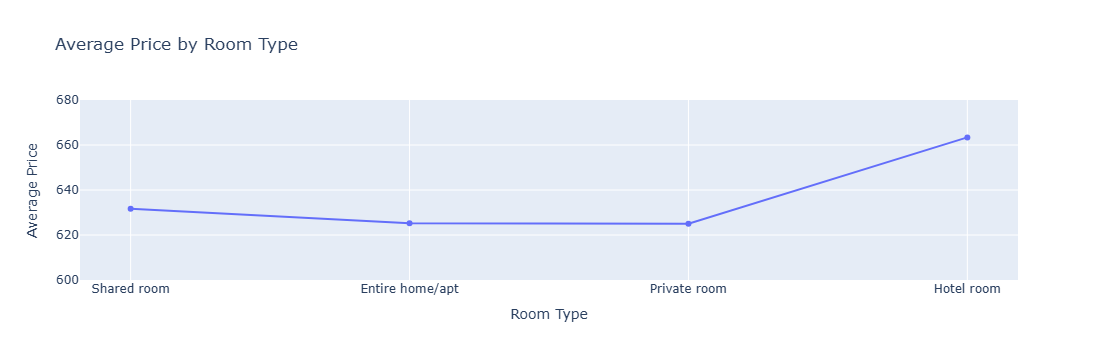

In [32]:
# Grouping rooms by type and calculating the average price
price_by_room = df.groupBy("room_type") \
    .agg(avg("price").alias("avg_price")) \
    .collect()  

# Data extraction from lists
categories = [row["room_type"] for row in price_by_room]
prices = [row["avg_price"] for row in price_by_room]

# Create line chart
fig = px.line(
    x=categories, 
    y=prices, 
    markers=True,
    title="Average Price by Room Type",
    labels={"x": "Room Type", "y": "Average Price"}
)

fig.update_layout(yaxis_range=[600, 680])

fig.show()

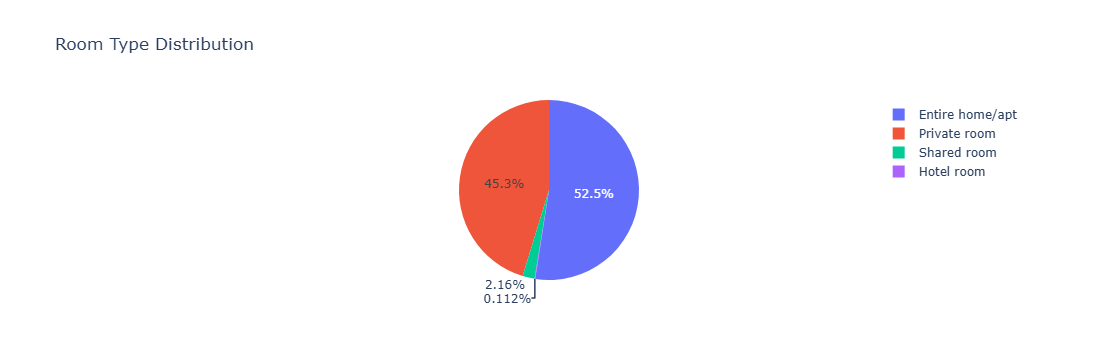

In [33]:
# Grouping lists by room type and number of rooms
room_count = df.groupBy("room_type").count().collect()

# Create pie chart
fig = px.pie(
    names=[row["room_type"] for row in room_count],
    values=[row["count"] for row in room_count],
    title="Room Type Distribution"
)

fig.show()

In [34]:

# Add a column that categorizes prices into 3 categories
df_with_category = df.withColumn(
    "price_category",
    when(col("price") <= 100, "Budget")
    .when(col("price") <= 300, "Mid-Range")
    .otherwise("Luxury")
)

# Calculate average rating for each price category
price_rating = df_with_category.groupBy("price_category") \
    .agg(
        count("*"),
        round(avg("review_rate_number"), 2).alias("avg_rating"),
        round(avg("number_of_reviews"), 1).alias("avg_reviews")
    ).collect()

# Convert to lists for plotting
categories = [row["price_category"] for row in price_rating] 
ratings = [row["avg_rating"] for row in price_rating]

# Sort by rating
sorted_pairs = sorted(zip(ratings, categories))
ratings_sorted = [p[0] for p in sorted_pairs]
categories_sorted = [p[1] for p in sorted_pairs]

# Create horizontal bar chart
fig = px.bar(
    x=ratings_sorted,
    y=categories_sorted,
    title="Price compared to rating",
    labels={"x": "Average Rating", "y": "Price Category"},
)
fig.update_layout(
    width=600,
    xaxis_range=[3, 3.5]
)

fig.show()

In [35]:

#Grouping results by host name
top_hosts = df.groupBy("host_name") \
    .agg(
        count("*").alias("total_units"),
        round(avg("price"), 2)).orderBy(col("total_units").desc()).limit(10) .collect()

hosts = [row["host_name"] for row in top_hosts]
property_count = [row["total_units"] for row in top_hosts]

fig = px.bar(
    x=property_count,  # Changed from units to property_count
    y=hosts,
    title="Top 10 Hosts",
    labels={"x": "Total Properties", "y": "Host Name"},
)

# Sort the results from top to bottom
fig.update_layout(
    width=800,
    height=500,
    yaxis={'categoryorder': 'total ascending'}
)

fig.show()

In [36]:
print("Availability distribution")
# Add a column that categorizes availability into 4 levels
availability = df.withColumn(
    "availability_level",
    when(col("availability_365") <= 30, "Rare")
    .when(col("availability_365") <= 150, "Medium")
    .when(col("availability_365") <= 300, "Often")
    .otherwise("Always")
)
# Calculating the number of properties at each level
availability_count = availability.groupBy("availability_level").agg(
        count("*").alias("total_units"),
        round(avg("price"), 2).alias("avg_price")
    ) .orderBy(col("availability_level")) .collect()

# Convert to lists for plotting
levels = [row["availability_level"] for row in availability_count]
counts = [row["total_units"] for row in availability_count]

fig = px.pie(
    names=levels,
    values=counts,
    title="Availability Distribution"
)

fig.update_traces(textposition='inside', textinfo='percent+label')
fig.update_layout(width=600, height=600)

fig.show()

Availability distribution
